Andrea Keiper and Alex Weinstein
DS4420 Final Project
April 16, 2026

MODEL 1: MANUALLY IMPLEMENTED MULTI-LAYER PERCEPTION

In [1]:
import pandas as pd
import numpy as np
import re

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
df = pd.read_csv("Boston_CrashDetails.csv", header=2)
df.head(5)

,Crash_Number,City_Town_Name,Crash_Date,Crash_Time,Crash_Severity,Maximum_Injury_Severity_Reported,Number_of_Vehicles,Total_Nonfatal_Injuries,Total_Fatal_Injuries,Manner_of_Collision,...,Ambient_Light,Weather_Condition,At_Roadway_Intersection,Distance_From_Nearest_Roadway_Intersection,Distance_From_Nearest_Milemarker,Distance_From_Nearest_Exit,Distance_From_Nearest_Landmark,Non_Motorist_Type,X_Cooordinate,Y_Cooordinate
0,2725539,BOSTON,01-Jan-2010,2:00 AM,Non-fatal injury,Non-fatal injury - Incapacitating,2,3,0,Rear-end,...,Daylight,"Sleet, hail (freezing rain or drizzle)",MORTON STREET / BLUE HILL AVENUE,MORTON STREET / BLUE HILL AVENUE,NaN,NaN,NaN,NaN,233688.296913,892724.750056
1,2576250,BOSTON,01-Jan-2010,2:02 AM,Not Reported,Not reported,2,0,0,Unknown,...,Dark - lighted roadway,Cloudy/Cloudy,BUNKER HILL STREET / ELM STREET,BUNKER HILL STREET / ELM STREET,NaN,NaN,NaN,NaN,236018.656211,903256.749810
2,2551708,BOSTON,01-Jan-2010,2:30 AM,Non-fatal injury,Non-fatal injury - Non-incapacitating,2,1,0,Angle,...,Dark - lighted roadway,Cloudy,NaN,COLUMBIA ROAD / BUTTONWOOD STREET,NaN,NaN,NaN,NaN,236609.587155,896844.662508
3,2560608,BOSTON,01-Jan-2010,2:32 AM,Property damage only (none injured),No injury,2,0,0,Rear-end,...,Dark - lighted roadway,Not Reported,MORTON STREET,MORTON STREET,NaN,NaN,NaN,NaN,NaN,NaN
4,2553095,BOSTON,01-Jan-2010,2:44 AM,Property damage only (none injured),No injury,1,0,0,Single vehicle crash,...,Dark - lighted roadway,Clear,NaN,Rte 90 W,Rte 90 W Milemarker 132.0,NaN,NaN,NaN,232572.239552,899870.482914


DATA CLEANING

In [3]:
# What does vehicle type currently look like?
df['Vehicle_Configuration'].unique()

array(['V1:(Passenger car) / V2:(Passenger car)',
       'V1:(Light truck(van, mini-van, pickup, sport utility))',
       'V1:(Passenger car)',
       'V1:(Light truck(van, mini-van, pickup, sport utility)) / V2:(Passenger car) / V3:(Passenger car)',
       nan, 'V1:(Passenger car) / V2:(Truck/trailer)',
       'V1:(Light truck(van, mini-van, pickup, sport utility)) / V2:(Passenger car)',
       'V1:(Light truck(van, mini-van, pickup, sport utility)) / V2:(Light truck(van, mini-van, pickup, sport utility))',
       'V1:(Passenger car) / V2:(Passenger car) / V3:(Light truck(van, mini-van, pickup, sport utility)) / V4:(Passenger car)',
       'V1:(Passenger car) / V2:(Light truck(van, mini-van, pickup, sport utility))',
       'V1:(Passenger car) / V2:(Light truck(van, mini-van, pickup, sport utility)) / V3:(Light truck(van, mini-van, pickup, sport utility))',
       'V2:(Light truck(van, mini-van, pickup, sport utility))',
       'V1:(Passenger car) / V2:(Bus (seats for 9-15 people, inc

In [4]:
# 1. Clean vehicles, currently formatted to include ALL vehicles involved in the crash, I want to keep the largest vehicle involved
VEHICLE_RANK = {
    'Tractor/triples':                                  1,
    'Tractor/doubles':                                  1,
    'Tractor/semi-trailer':                             1,
    'Truck tractor (bobtail':                           2,
    'Single-unit truck (3-or-more axles':               2,
    'Unknown heavy truck, cannot classify':             2,
    'Single-unit truck (2-axle, 6-tires':               3,
    'Truck/trailer':                                    3,
    'Bus (seats for 16 or more, including driver':      4,
    'Bus (seats for 9-15 people, including driver':     4,
    'Motor home/recreational vehicle':                  5,
    'Light truck(van, mini-van, pickup, sport utility': 6,
    'Passenger car':                                    7,
    'Motorcycle':                                       8,
    'MOPED':                                            9,
    'All Terrain Vehicle (ATV':                         9,
    'Snowmobile':                                       9,
    'Low Speed Vehicle':                                9,
    'Registered farm equipment':                        9,
}

def largest_vehicle(val):
    # Extract all Vn types; return the one with the lowest rank number (= biggest vehicle)
    if pd.isna(val):
        return None
    matches = re.findall(r'V\d+:\((.+?)\)', str(val))
    if not matches:
        return None
    ranked = [(VEHICLE_RANK.get(m.strip(), 99), m.strip()) for m in matches]
    return min(ranked, key=lambda x: x[0])[1]
 
df['Vehicle_Type'] = df['Vehicle_Configuration'].apply(largest_vehicle)
 
# Consolidate into broad categories for one-hot encoding
VEHICLE_CATEGORY = {
    'Tractor/triples':                                  'Heavy Truck',
    'Tractor/doubles':                                  'Heavy Truck',
    'Tractor/semi-trailer':                             'Heavy Truck',
    'Truck tractor (bobtail':                           'Heavy Truck',
    'Single-unit truck (3-or-more axles':               'Heavy Truck',
    'Unknown heavy truck, cannot classify':             'Heavy Truck',
    'Single-unit truck (2-axle, 6-tires':               'Medium Truck',
    'Truck/trailer':                                    'Medium Truck',
    'Bus (seats for 16 or more, including driver':      'Bus',
    'Bus (seats for 9-15 people, including driver':     'Bus',
    'Motor home/recreational vehicle':                  'Light Truck/Van',
    'Light truck(van, mini-van, pickup, sport utility': 'Light Truck/Van',
    'Passenger car':                                    'Passenger Car',
    'Motorcycle':                                       'Motorcycle/Moped',
    'MOPED':                                            'Motorcycle/Moped',
    'All Terrain Vehicle (ATV':                         'Other',
    'Snowmobile':                                       'Other',
    'Low Speed Vehicle':                                'Other',
    'Registered farm equipment':                        'Other',
}

df['Largest_Vehicle'] = df['Vehicle_Type'].map(VEHICLE_CATEGORY)

In [5]:
# 2. Clean intersection data
# Currently names the intersection if it's at an intersection, making it binary
df['At_Intersection'] = df['At_Roadway_Intersection'].notna().astype(int)


In [6]:
# 3. Clean weather
# Simplify: strip multi-condition combos (e.g. "Clear/Rain" -> "Clear")
df['Weather_Simple'] = df['Weather_Condition'].apply(
    lambda x: str(x).split('/')[0].strip() if pd.notna(x) else None
)

print("Value Counts")
print(df['Weather_Simple'].value_counts())

# Keeping the top 7 most common (Unknown and Other will be removed later, so this is really top 5), for simplicity sake since we are one-hot encoding
top_weather = df['Weather_Simple'].value_counts().nlargest(7).index
df['Weather_Simple'] = df['Weather_Simple'].apply(
    lambda x: x if x in top_weather else ('Other' if pd.notna(x) else None)
)

Value Counts
Weather_Simple
Clear                                     49207
Cloudy                                     9922
Rain                                       7232
Not Reported                               6247
Snow                                       1364
Unknown                                     383
Sleet, hail (freezing rain or drizzle)      245
Other                                       167
Fog, smog, smoke                             63
Blowing sand, snow                           24
Severe crosswinds                            24
Reported but invalid                          1
Name: count, dtype: int64


PREPARE MLP

In [7]:
# TARGET: Binary Crash Severity
# 1 = any injury (fatal or non-fatal)
# 0 = property damage only / no injury
print(df['Crash_Severity'].unique())

# Remove unknowns and nan
df = df[~df['Crash_Severity'].isin(['Not Reported', 'Unknown']) & df['Crash_Severity'].notna()].copy()

# Binary encode
injury_labels = {'Non-fatal injury', 'Fatal injury'}
df['severity_binary'] = df['Crash_Severity'].apply(
    lambda x: 1 if x in injury_labels else 0
)


['Non-fatal injury' 'Not Reported' 'Property damage only (none injured)'
 'Unknown' 'Fatal injury' nan]


In [8]:
CAT_FEATURES = ['Vehicle_Type', 'Road_Surface_Condition', 'Ambient_Light', 'Weather_Simple']
FEATURES = ['Vehicle_Type', 'Road_Surface_Condition', 'Ambient_Light', 'Weather_Simple', 'At_Intersection', 'severity_binary']
 
feature_df = df[FEATURES].dropna(subset=CAT_FEATURES).copy()
 
# Remove all ambiguous values
remove = {'Unknown', 'Not reported', 'Not Reported', 'Not Applicable', 'Other'}
mask = ~feature_df[CAT_FEATURES].apply(lambda col: col.isin(remove)).any(axis=1)
feature_df = feature_df[mask].copy()
feature_df = feature_df[feature_df[FEATURES].notna().all(axis=1)] 

print(f"Clean records: {len(feature_df):,}")
print(f"Class balance:\n{feature_df['severity_binary'].value_counts()}\n")

Clean records: 58,860
Class balance:
severity_binary
0    40091
1    18769
Name: count, dtype: int64



In [9]:
# ONE-HOT ENCODE & SCALE

encoded_df = pd.get_dummies(feature_df, columns=CAT_FEATURES, drop_first=True, dtype=int)
 
y = encoded_df['severity_binary'].to_numpy().astype(float)
X_raw = encoded_df.drop(columns=['severity_binary']).to_numpy().astype(float)
 
print(f"Feature matrix: {X_raw.shape}  ({X_raw.shape[1]} columns after one-hot)\n")
 
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
col_range = X_max - X_min
col_range[col_range == 0] = 1
X_scaled  = ((X_raw - X_min) / col_range).round(4)
 
# Add bias column
X_bias = np.concatenate([np.ones((X_scaled.shape[0], 1)), X_scaled], axis=1)

Feature matrix: (58860, 34)  (34 columns after one-hot)



TRAIN TEST SPLIT

In [10]:
np.random.seed(42)
n_total   = X_bias.shape[0]
indices   = np.random.permutation(n_total)
 
# Slice 70% train, 30% test
n_train   = int(n_total * 0.7)
train_idx = indices[:n_train]
test_idx  = indices[n_train:]
 
X_train, X_test = X_bias[train_idx], X_bias[test_idx]
y_train, y_test = y[train_idx],      y[test_idx]
 
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}\n")

Train: 41,202  |  Test: 17,658



MLP SETUP

In [27]:
# Input -> Hidden (ReLU) -> Output (Sigmoid)

np.random.seed(30)
 
d = X_train.shape[1]
h_size = 32
eta = 0.01
epochs = 2000
 
W1 = np.random.randn(d, h_size) # (input_dim x hidden_size)
W2 = np.random.randn(h_size, 1) # (hidden_size x 1)

MANUALLY IMPLEMENTED MULTI LAYER PERCEPTRON

In [28]:
train_losses = []
test_losses  = []
 
for epoch in range(epochs):
    # --- Forward pass (train) ---
    H     = np.maximum(0, X_train @ W1)
    logit = H @ W2
    Y_hat = 1 / (1 + np.exp(-logit))
 
    y_col = y_train.reshape(-1, 1)
    error = Y_hat - y_col
 
    # --- Train loss ---
    eps        = 1e-9
    train_loss = -np.mean(
        y_col * np.log(Y_hat + eps) + (1 - y_col) * np.log(1 - Y_hat + eps)
    )
    train_losses.append(float(train_loss))
 
    # --- Test loss (forward pass only, no weight update) ---
    H_test     = np.maximum(0, X_test @ W1)
    Y_hat_test = 1 / (1 + np.exp(-(H_test @ W2)))
    y_test_col = y_test.reshape(-1, 1)
    test_loss  = -np.mean(
        y_test_col * np.log(Y_hat_test + eps) + (1 - y_test_col) * np.log(1 - Y_hat_test + eps)
    )
    test_losses.append(float(test_loss))
 
    # --- Backward pass ---
    dW2 = (1 / len(X_train)) * (H.T @ error)
    relu_mask = (X_train @ W1 > 0).astype(float)
    delta_h   = (error @ W2.T) * relu_mask
    dW1       = (1 / len(X_train)) * (X_train.T @ delta_h)
 
    W1 -= eta * dW1
    W2 -= eta * dW2
 
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3}/{epochs}  |  Train Loss: {train_loss:.4f}  |  Test Loss: {test_loss:.4f}")
 
print()

Epoch  50/2000  |  Train Loss: 1.2661  |  Test Loss: 1.2475
Epoch 100/2000  |  Train Loss: 1.0956  |  Test Loss: 1.0816
Epoch 150/2000  |  Train Loss: 0.9864  |  Test Loss: 0.9748
Epoch 200/2000  |  Train Loss: 0.9221  |  Test Loss: 0.9124
Epoch 250/2000  |  Train Loss: 0.8834  |  Test Loss: 0.8752
Epoch 300/2000  |  Train Loss: 0.8589  |  Test Loss: 0.8518
Epoch 350/2000  |  Train Loss: 0.8418  |  Test Loss: 0.8355
Epoch 400/2000  |  Train Loss: 0.8285  |  Test Loss: 0.8228
Epoch 450/2000  |  Train Loss: 0.8175  |  Test Loss: 0.8124
Epoch 500/2000  |  Train Loss: 0.8081  |  Test Loss: 0.8034
Epoch 550/2000  |  Train Loss: 0.7996  |  Test Loss: 0.7953
Epoch 600/2000  |  Train Loss: 0.7920  |  Test Loss: 0.7881
Epoch 650/2000  |  Train Loss: 0.7852  |  Test Loss: 0.7816
Epoch 700/2000  |  Train Loss: 0.7790  |  Test Loss: 0.7755
Epoch 750/2000  |  Train Loss: 0.7732  |  Test Loss: 0.7700
Epoch 800/2000  |  Train Loss: 0.7677  |  Test Loss: 0.7648
Epoch 850/2000  |  Train Loss: 0.7627  |

In [31]:
def predict_batch(X, W1, W2, threshold=0.4):
    # Reduced threshold from 0.5 (original) to 0.4 to increase true positives while retaining adequate accuracy (a tradeoff)
    H     = np.maximum(0, X @ W1)
    Y_hat = 1 / (1 + np.exp(-(H @ W2)))
    return (Y_hat.squeeze() >= threshold).astype(int)
 
y_pred_train = predict_batch(X_train, W1, W2)
y_pred_test  = predict_batch(X_test,  W1, W2)
 
train_acc = np.mean(y_pred_train == y_train)
test_acc  = np.mean(y_pred_test  == y_test)
 
print(f"Train Accuracy : {train_acc*100:.1f}%")
print(f"Test  Accuracy : {test_acc*100:.1f}%\n")
 
TP = int(np.sum((y_pred_test == 1) & (y_test == 1)))
TN = int(np.sum((y_pred_test == 0) & (y_test == 0)))
FP = int(np.sum((y_pred_test == 1) & (y_test == 0)))
FN = int(np.sum((y_pred_test == 0) & (y_test == 1)))
 
precision = TP / (TP + FP + 1e-9)
recall    = TP / (TP + FN + 1e-9)
f1        = 2 * precision * recall / (precision + recall + 1e-9)
 
print("Confusion Matrix (Test Set):")
print(f"  TP={TP:>5}  FP={FP:>5}")
print(f"  FN={FN:>5}  TN={TN:>5}")
print(f"\nPrecision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Train Accuracy : 63.9%
Test  Accuracy : 63.9%

Confusion Matrix (Test Set):
  TP= 1309  FP= 1960
  FN= 4409  TN= 9980

Precision : 0.4004
Recall    : 0.2289
F1 Score  : 0.2913


In [33]:
H_test    = np.maximum(0, X_test @ W1)
Y_probs   = 1 / (1 + np.exp(-(H_test @ W2))).squeeze()
 
def evaluate(probs, y_true, threshold):
    preds = (probs >= threshold).astype(int)
    TP = int(np.sum((preds == 1) & (y_true == 1)))
    TN = int(np.sum((preds == 0) & (y_true == 0)))
    FP = int(np.sum((preds == 1) & (y_true == 0)))
    FN = int(np.sum((preds == 0) & (y_true == 1)))
    acc       = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-9)
    recall    = TP / (TP + FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    return TP, TN, FP, FN, acc, precision, recall, f1
 
TP, TN, FP, FN, acc, precision, recall, f1 = evaluate(Y_probs, y_test, threshold=0.4)
 
print(f"Test Accuracy  : {acc*100:.1f}%")
print(f"Confusion Matrix (threshold=0.4):")
print(f"  TP={TP:>5}  FP={FP:>5}")
print(f"  FN={FN:>5}  TN={TN:>5}")
print(f"Precision : {precision:.4f}  |  Recall : {recall:.4f}  |  F1 : {f1:.4f}")

Test Accuracy  : 63.9%
Confusion Matrix (threshold=0.4):
  TP= 1309  FP= 1960
  FN= 4409  TN= 9980
Precision : 0.4004  |  Recall : 0.2289  |  F1 : 0.2913


In [36]:
# Threshold tuning
thresholds = np.arange(0.1, 0.91, 0.05)
 
print(f"\n{'Threshold':>10} {'Accuracy':>10} {'TP':>7} {'FP':>7} {'FN':>7} {'TN':>7} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 80)
 
results = []
for t in thresholds:
    TP, TN, FP, FN, acc, precision, recall, f1 = evaluate(Y_probs, y_test, t)
    results.append((t, acc, TP, FP, FN, TN, precision, recall, f1))
    print(f"{t:>10.2f} {acc*100:>9.1f}% {TP:>7} {FP:>7} {FN:>7} {TN:>7} {precision:>10.4f} {recall:>8.4f} {f1:>8.4f}")
 
results = np.array([(r[0], r[1], r[2], r[6], r[7], r[8]) for r in results],
                   dtype=[('threshold','f4'),('acc','f4'),('TP','i4'),
                          ('precision','f4'),('recall','f4'),('f1','f4')])
best_f1  = results[np.argmax(results['f1'])]
best_rec = results[np.argmax(results['recall'])]
print(f"\nBest F1       → threshold={best_f1['threshold']:.2f}  F1={best_f1['f1']:.4f}  TP={best_f1['TP']}")
print(f"Best Recall   → threshold={best_rec['threshold']:.2f}  Recall={best_rec['recall']:.4f}  TP={best_rec['TP']}")


 Threshold   Accuracy      TP      FP      FN      TN  Precision   Recall       F1
--------------------------------------------------------------------------------
      0.10      34.8%    5407   11200     311     740     0.3256   0.9456   0.4844
      0.15      35.9%    5218   10822     500    1118     0.3253   0.9126   0.4796
      0.20      39.0%    4896    9955     822    1985     0.3297   0.8562   0.4761
      0.25      48.1%    3919    7361    1799    4579     0.3474   0.6854   0.4611
      0.30      48.8%    3830    7146    1888    4794     0.3489   0.6698   0.4588
      0.35      57.5%    2580    4366    3138    7574     0.3714   0.4512   0.4075
      0.40      63.9%    1309    1960    4409    9980     0.4004   0.2289   0.2913
      0.45      65.7%     946    1282    4772   10658     0.4246   0.1654   0.2381
      0.50      66.2%     340     586    5378   11354     0.3672   0.0595   0.1023
      0.55      66.4%     278     485    5440   11455     0.3644   0.0486   0.0858
     

Loss curves saved to boston_crash_mlp_loss.png


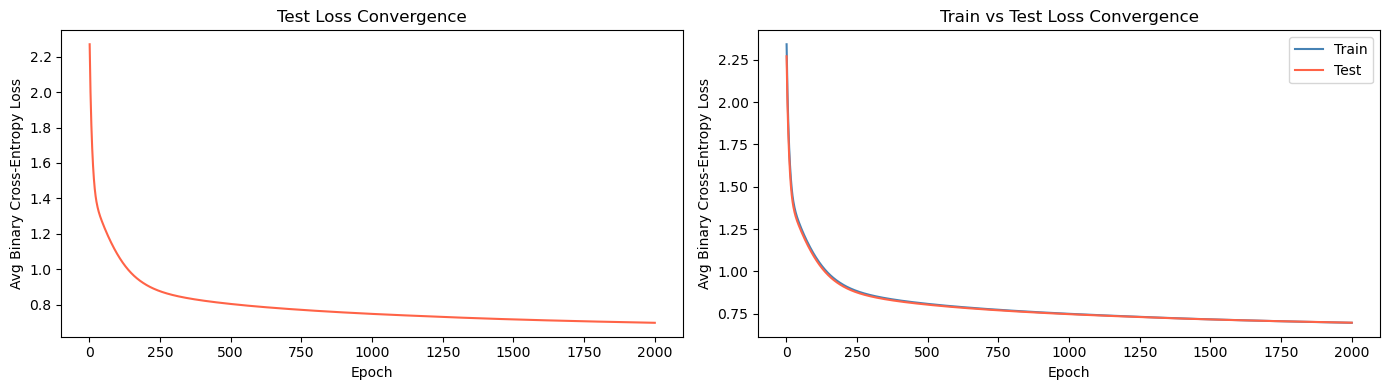

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Left plot: test loss only
axes[0].plot(range(1, epochs + 1), test_losses, color='tomato', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Avg Binary Cross-Entropy Loss')
axes[0].set_title('Test Loss Convergence')
 
# Right plot: train vs test loss
axes[1].plot(range(1, epochs + 1), train_losses, color='steelblue', linewidth=1.5, label='Train')
axes[1].plot(range(1, epochs + 1), test_losses,  color='tomato',    linewidth=1.5, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Avg Binary Cross-Entropy Loss')
axes[1].set_title('Train vs Test Loss Convergence')
axes[1].legend()
 
plt.tight_layout()
plt.savefig('boston_crash_mlp_loss.png', dpi=150)
print("Loss curves saved to boston_crash_mlp_loss.png")

In [ ]:
# POSTER VISUALIZATIONS
POSTER_THRESHOLD = 0.4  # chosen threshold for final evaluation
 
TP, TN, FP, FN, acc, precision, recall, f1 = evaluate(Y_probs, y_test, POSTER_THRESHOLD)
 
#  Figure 1: Confusion Matrix Heatmap 
fig, ax = plt.subplots(figsize=(5, 4))
cm = np.array([[TN, FP], [FN, TP]])
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
 
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nNo Injury', 'Predicted\nInjury'], fontsize=11)
ax.set_yticklabels(['Actual\nNo Injury', 'Actual\nInjury'], fontsize=11)
 
for i, row in enumerate(cm):
    for j, val in enumerate(row):
        ax.text(j, i, f'{val:,}', ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
 
ax.set_title(f'Confusion Matrix (threshold={POSTER_THRESHOLD})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('poster_confusion_matrix.png', dpi=150)
plt.close()
print("Saved poster_confusion_matrix.png")
 


Saved poster_confusion_matrix.png


In [ ]:
# Figure 2: Threshold vs Precision / Recall / F1 
thresh_vals  = [r[0] for r in results]
prec_vals    = [r[3] for r in results]
rec_vals     = [r[4] for r in results]
f1_vals      = [r[5] for r in results]
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresh_vals, prec_vals, color='steelblue',  linewidth=2, marker='o', markersize=4, label='Precision')
ax.plot(thresh_vals, rec_vals,  color='tomato',     linewidth=2, marker='o', markersize=4, label='Recall')
ax.plot(thresh_vals, f1_vals,   color='seagreen',   linewidth=2, marker='o', markersize=4, label='F1')
ax.axvline(x=POSTER_THRESHOLD, color='gray', linestyle='--', linewidth=1.2, label=f'Chosen threshold ({POSTER_THRESHOLD})')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall & F1 vs Decision Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('poster_threshold_curves.png', dpi=150)
plt.close()
print("Saved poster_threshold_curves.png")
 


Saved poster_threshold_curves.png


In [ ]:
#  Figure 3: Class Distribution Before / After Balancing 

# IF I DECIDE TO SAMPLE!!!


# fig, axes = plt.subplots(1, 2, figsize=(8, 4))
 
# # Before
# before_counts = [int((y == 0).sum()), int((y == 1).sum())]
# axes[0].bar(['No Injury', 'Injury'], before_counts, color=['steelblue', 'tomato'], edgecolor='white')
# axes[0].set_title('Original Class Distribution', fontsize=12, fontweight='bold')
# axes[0].set_ylabel('Record Count', fontsize=11)
# for i, v in enumerate(before_counts):
#     axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
 
# # After
# after_counts = [int((y_balanced == 0).sum()), int((y_balanced == 1).sum())]
# axes[1].bar(['No Injury', 'Injury'], after_counts, color=['steelblue', 'tomato'], edgecolor='white')
# axes[1].set_title('Balanced Class Distribution (Undersampled)', fontsize=12, fontweight='bold')
# axes[1].set_ylabel('Record Count', fontsize=11)
# for i, v in enumerate(after_counts):
#     axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
 
# plt.tight_layout()
# plt.savefig('poster_class_distribution.png', dpi=150)
# plt.close()
# print("Saved poster_class_distribution.png")
 


Saved poster_class_distribution.png


In [43]:
feature_names = encoded_df.drop(columns=['severity_binary']).columns.tolist()
# Average absolute weight across all hidden nodes for each input feature
importance = np.abs(W1[1:, :]).mean(axis=1)  # skip bias row (index 0)
 
# Group importance scores by feature category (sum within group)
def get_group(name):
    if name == 'At_Intersection':            return ('At Intersection', name)
    if name.startswith('Vehicle_Type_'):     return ('Vehicle Type',    name.replace('Vehicle_Type_', ''))
    if name.startswith('Road_Surface'):      return ('Road Surface',    name.replace('Road_Surface_Condition_', ''))
    if name.startswith('Ambient_Light_'):    return ('Ambient Light',   name.replace('Ambient_Light_', ''))
    if name.startswith('Weather_Simple_'):   return ('Weather',         name.replace('Weather_Simple_', ''))
    return ('Other', name)
 
# Build grouped importance: sum absolute weights per category
from collections import defaultdict
group_importance = defaultdict(float)
for fname, imp in zip(feature_names, importance):
    group, _ = get_group(fname)
    group_importance[group] += imp
 
groups = list(group_importance.keys())
values = [group_importance[g] for g in groups]
 
# Sort by importance
sorted_pairs = sorted(zip(values, groups), reverse=True)
sorted_vals  = [p[0] for p in sorted_pairs]
sorted_grps  = [p[1] for p in sorted_pairs]
 
# Color each bar by category
palette = {
    'Vehicle Type':   'steelblue',
    'Road Surface':   'seagreen',
    'Ambient Light':  'darkorange',
    'Weather':        'mediumpurple',
    'At Intersection':'tomato',
}
colors = [palette.get(g, 'gray') for g in sorted_grps]
 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(sorted_grps[::-1], sorted_vals[::-1], color=colors[::-1], edgecolor='white', height=0.6)
 
# Add value labels on bars
for bar, val in zip(bars, sorted_vals[::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)
 
ax.set_xlabel('Sum of Avg Absolute W1 Weights', fontsize=11)
ax.set_title('Feature Group Importance (via W1 Weights)', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(sorted_vals) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('poster_feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved poster_feature_importance.png")

Saved poster_feature_importance.png


In [ ]:
# Dr. Gerber convo notes

# Downsample
# Remove data from uninjured dataset so that it is half / half uninjured and injured 
# Stratified Random Sampling

# EVALUATE
# Check test loss vs train loss
# If overfitting, decrease number of nodes 
# Drop out: Each epoch randomly choose some of the weights and set to 0 JUST for that epoch 
# Update objective function to have a penalty term
# Fiddle with activitation (ReLU vs leaky ReLU vs sigmoid)
# Decrease number of inputs